In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=pd.read_csv('diet.csv')
data_copy=data.copy()# its for my project backup
data.head(3)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic


In [114]:
data['Diet']# multi class clasiification problem 
#column is target columns

0           Low Carb
1           Diabetic
2           Diabetic
3           Diabetic
4      Heart Healthy
           ...      
995         Diabetic
996         Diabetic
997         Low Carb
998         Diabetic
999         Diabetic
Name: Diet, Length: 1000, dtype: object

In [115]:
data.duplicated().sum()

0

In [116]:
data.isnull().sum()

Age               0
Gender            0
Height_cm         0
Weight_kg         0
BMI               0
Activity_Level    0
Sugar_Level       0
Cholesterol       0
Goal              0
Diet              0
dtype: int64

In [117]:
data.describe()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,0.476000,167.139000,79.231000,28.914300,0.974000,125.762000,210.460000,0.979000
std,13.765677,0.499674,13.142237,22.550525,9.524523,0.823409,31.838012,40.539238,0.804491
min,18.000000,0.000000,145.000000,40.000000,11.100000,0.000000,70.000000,140.000000,0.000000
25%,30.000000,0.000000,156.000000,60.000000,21.100000,0.000000,98.000000,174.000000,0.000000
50%,42.000000,0.000000,166.500000,79.000000,28.150000,1.000000,127.000000,214.000000,1.000000
75%,53.000000,1.000000,178.000000,99.000000,35.600000,2.000000,153.000000,246.000000,2.000000
max,65.000000,1.000000,190.000000,120.000000,56.100000,2.000000,180.000000,280.000000,2.000000


In [118]:
data.shape

(1000, 10)

In [119]:
data.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet'],
      dtype='object')

In [120]:
data.dtypes

Age                 int64
Gender              int64
Height_cm           int64
Weight_kg           int64
BMI               float64
Activity_Level      int64
Sugar_Level         int64
Cholesterol         int64
Goal                int64
Diet               object
dtype: object

In [121]:
#age is discrite ,gender is categorical nominal ()
#height,weight,bmi is cnotinus

In [122]:
data['Activity_Level'].value_counts()

Activity_Level
0    352
2    326
1    322
Name: count, dtype: int64

In [123]:
data['BMI']#contious

0      56.1
1      22.5
2      28.7
3      44.2
4      24.4
       ... 
995    17.4
996    19.1
997    27.7
998    14.0
999    18.0
Name: BMI, Length: 1000, dtype: float64

In [124]:
data['Cholesterol']#disctre

0      169
1      253
2      256
3      199
4      237
      ... 
995    261
996    156
997    177
998    249
999    161
Name: Cholesterol, Length: 1000, dtype: int64

In [125]:
data['Goal'].value_counts()#its nominal its nn ordr data 1,0,2

Goal
1    353
0    334
2    313
Name: count, dtype: int64

In [126]:
data['Diet'].value_counts()#its highly imbalnce dataset its healthcare data

Diet
Diabetic         539
Low Carb         255
Heart Healthy     92
High Protein      70
Balanced          44
Name: count, dtype: int64

In [127]:
#univarity anylisis
data['Age'].head(2)

0    56
1    46
Name: Age, dtype: int64

<Axes: ylabel='Age'>

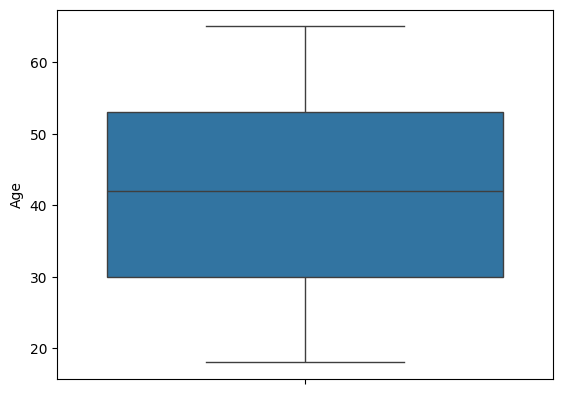

In [128]:
sns.boxplot(data['Age'])# no outlier

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\854362175.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])#we check gusssian


<Axes: xlabel='Age', ylabel='Density'>

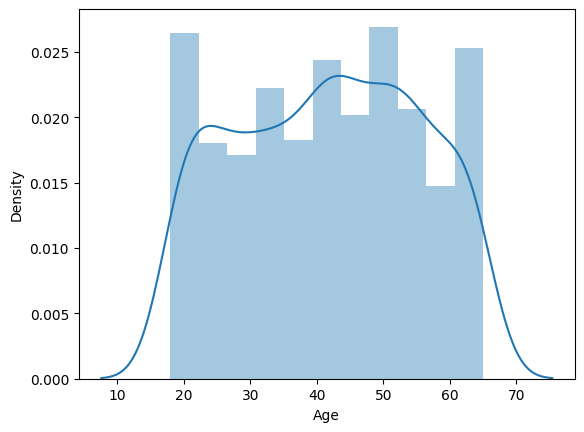

In [129]:
import seaborn as sns
sns.distplot(data['Age'])#we check gusssian

In [130]:
from scipy import stats
import matplotlib.pyplot as plt

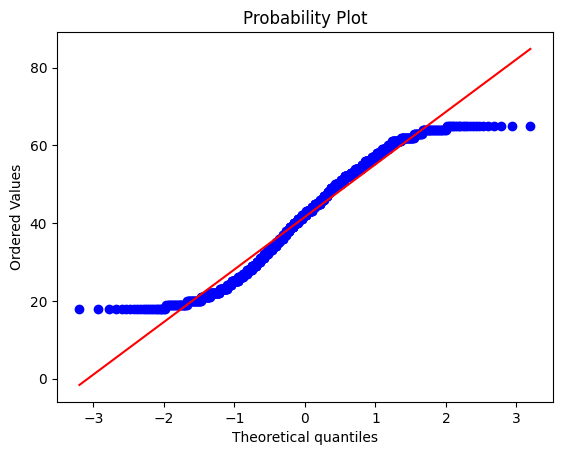

In [131]:
stats.probplot(data['Age'],dist='norm',plot=plt)
plt.show()

In [132]:
data['Age'].skew()

-0.04759933065573039

In [133]:
from scipy.stats import skew,kurtosis

In [134]:
skew(data['Age'])

-0.04752790188932369

In [135]:
kurtosis(data['Age'])

-1.138444126808074

In [136]:
from scipy.stats import kstest

In [137]:
n,p=kstest(data['Age'],cdf='norm',N=2)
n,p

(1.0, 0.0)

In [138]:
# you use Adtest

In [139]:
import numpy as np

def estimation_clt(data, sample_data, sample_size):
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))

    mean_array = np.array(sample_mean)
    
    return mean_array, np.mean(mean_array)

In [ ]:
data1=data['Age']
sample_data=1000
sample_size=30
array, estimated_mean = estimation_clt(data1, 1000, 30)
array,estimated_mean

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\1133588802.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(array)


<Axes: ylabel='Density'>

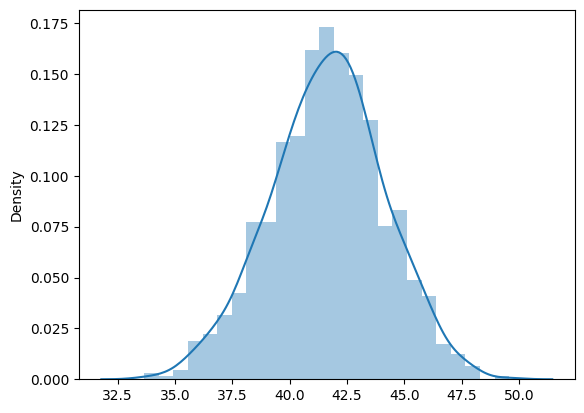

In [141]:
sns.distplot(array)

def boostraping(data1,sample_data,sample_size,ci):
    sample_mean=[]
    for i in range(sample_data):
        sample=np.random.choice(data,size=sample_size)
        sample_mean.append(np.mean(sample))
    sorted=np.sort(sample_mean)
    return sample_mean

In [143]:
import numpy as np

def boostraping(data, sample_data, sample_size, ci):
    data = np.array(data).flatten()   # make data 1D
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data, size=sample_size, replace=True)
        sample_mean.append(np.mean(sample))
    sample_mean = np.array(sample_mean)
    lower = np.percentile(sample_mean, (1-ci)/2 * 100)
    upper = np.percentile(sample_mean, (1+ci)/2 * 100)

    return lower, upper

In [144]:
data1=data['Age']
sample_data=1000
sample_size=30
ci=0.95
array=boostraping(data1,sample_data,sample_size,ci)
lower, upper = boostraping(data1, sample_data, sample_size, ci)
print("Confidence Interval:", lower, upper)

Confidence Interval: 36.465833333333336 46.50083333333333


In [145]:
#estimating of sd range estimating on  chebious enqulity
def std_chebisius_enqulity(mean, std, k):
    ll = mean - k * std   # lower limit
    ul = mean + k * std   # upper limit
    per = 1 - (1 / k**2)  # minimum probability
    
    return ll, ul, per
df = data['Age']
mean = np.mean(df)
std = np.std(df)
k = 3
# range estimation
ll, ul, per = std_chebisius_enqulity(mean, std, k)
print("Lower Limit:", ll)
print("Upper Limit:", ul)
print("Minimum Data Percentage:", per * 100, "%")

Lower Limit: 0.2986220702445337
Upper Limit: 82.85137792975547
Minimum Data Percentage: 88.88888888888889 %


In [146]:
np.max(data['Age'])

65

In [253]:
def fun(x):
    if  x<=25:
        return 'young'
    elif x>=26 and x<=45:
        return 'Adult'
    else:
        return 'old'
data['Age_categoric']=data['Age'].apply(fun)

In [254]:
data

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Sugar_Level_categorical,Age_categoric
0,56,0,145,118,56.1,0,131,169,2,Low Carb,high,old
1,46,1,166,62,22.5,0,118,253,2,Diabetic,Normal,old
2,32,0,170,83,28.7,1,78,256,2,Diabetic,Normal,Adult
3,60,1,162,116,44.2,2,161,199,0,Diabetic,high,old
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy,Normal,young
...,...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic,high,young
996,43,1,165,52,19.1,2,175,156,2,Diabetic,high,Adult
997,21,0,159,70,27.7,1,126,177,0,Low Carb,Normal,young
998,36,1,171,41,14.0,2,149,249,0,Diabetic,high,Adult


<Axes: xlabel='Age_categoric', ylabel='count'>

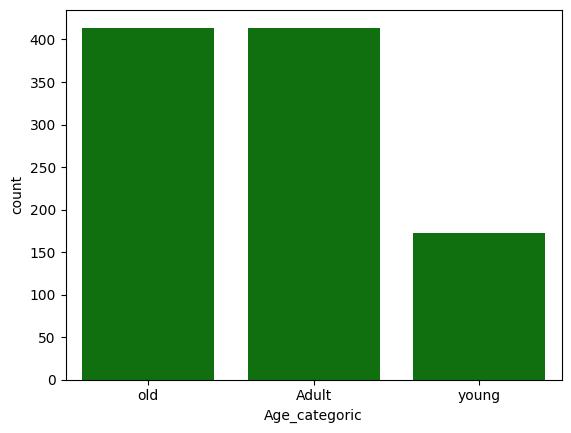

In [149]:
sns.barplot(data['Age_categoric'].value_counts(),color='g')

<Axes: xlabel='Gender'>

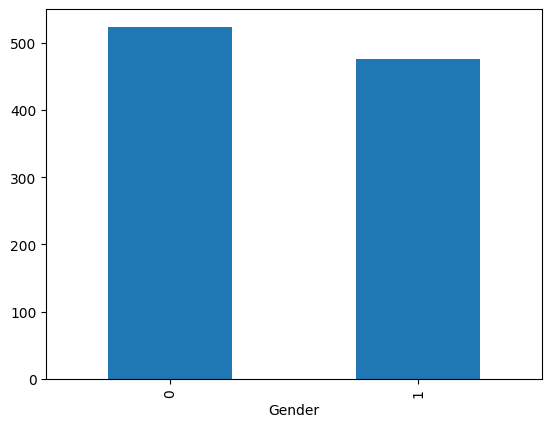

In [150]:
#gebder
data['Gender'].value_counts().plot(kind='bar')

Age_categoric
Adult    414
old      414
young    172
Name: Age, dtype: int64


<Axes: xlabel='Age_categoric', ylabel='Age'>

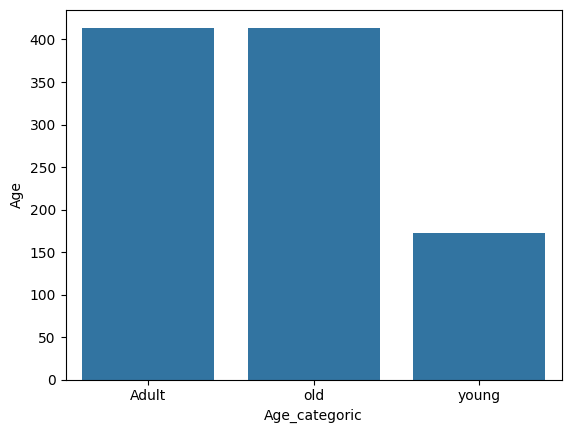

In [151]:
data_age_categoric=data.groupby('Age_categoric')['Age'].count()
print(data_age_categoric)
sns.barplot(data_age_categoric)

## Height 

<Axes: ylabel='Height_cm'>

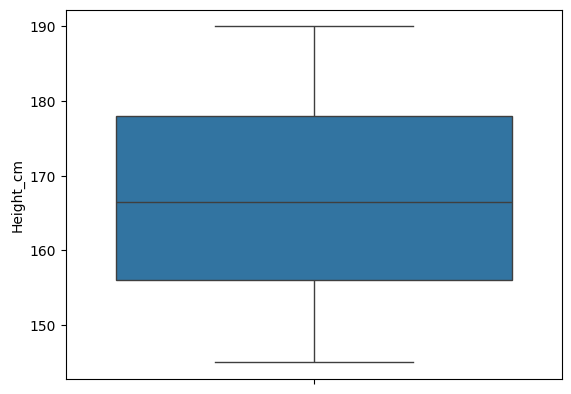

In [152]:
sns.boxplot(data['Height_cm'])

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\4259272396.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Height_cm'])


<Axes: xlabel='Height_cm', ylabel='Density'>

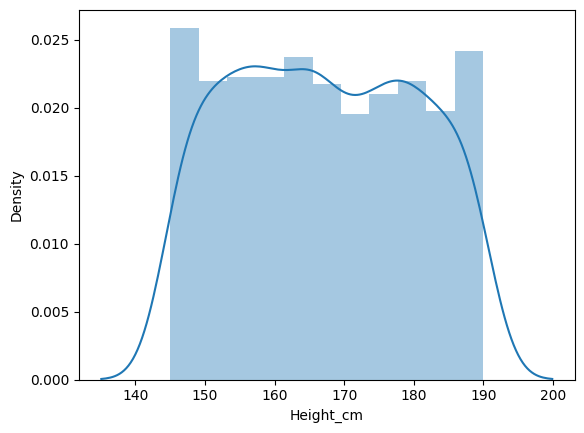

In [153]:
sns.distplot(data['Height_cm'])

In [154]:
from scipy.stats import probplot

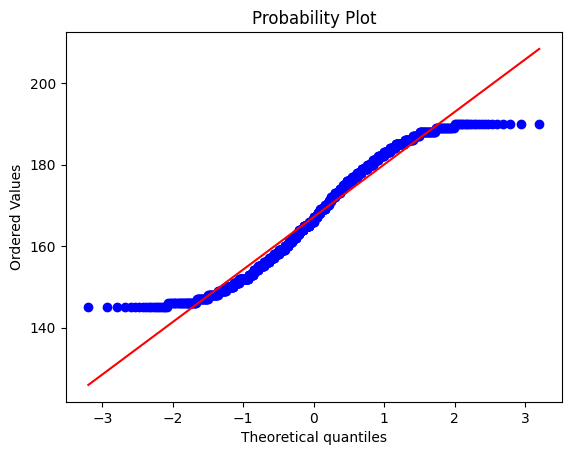

In [155]:
probplot(data['Height_cm'],dist='norm',plot=plt)
plt.show()

In [156]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   int64  
 1   Gender          1000 non-null   int64  
 2   Height_cm       1000 non-null   int64  
 3   Weight_kg       1000 non-null   int64  
 4   BMI             1000 non-null   float64
 5   Activity_Level  1000 non-null   int64  
 6   Sugar_Level     1000 non-null   int64  
 7   Cholesterol     1000 non-null   int64  
 8   Goal            1000 non-null   int64  
 9   Diet            1000 non-null   object 
 10  Age_categoric   1000 non-null   object 
dtypes: float64(1), int64(8), object(2)
memory usage: 86.1+ KB


In [157]:
# onverted 
data['Height_cm']=data['Height_cm'].astype('float')

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\4259272396.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Height_cm'])


<Axes: xlabel='Height_cm', ylabel='Density'>

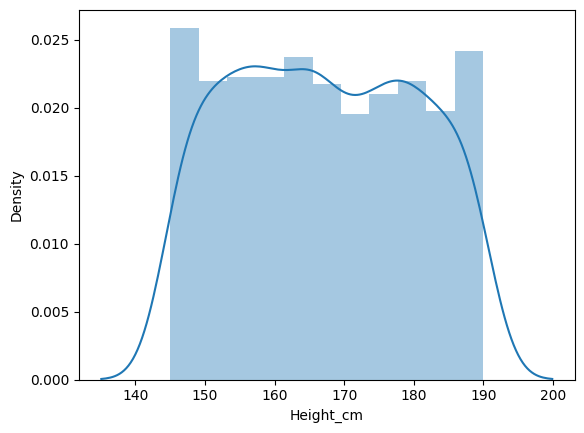

In [158]:
sns.distplot(data['Height_cm'])

In [159]:
def clt_estimation():
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))

    mean_array = np.array(sample_mean)
    
    return mean_array, np.mean(mean_array)

data1=data['Height_cm']
sample_data=1000
sample_size=30
array, estimated_mean = estimation_clt(data1, 1000, 30)
array,estimated_mean

(array([165.9       , 170.        , 169.96666667, 167.33333333,
        167.2       , 169.73333333, 163.        , 167.9       ,
        169.8       , 173.46666667, 167.7       , 168.66666667,
        164.5       , 163.26666667, 171.36666667, 166.4       ,
        171.86666667, 169.83333333, 172.03333333, 169.4       ,
        164.7       , 165.66666667, 163.56666667, 169.23333333,
        162.56666667, 168.9       , 169.3       , 166.76666667,
        169.7       , 171.83333333, 167.06666667, 167.36666667,
        168.66666667, 166.5       , 165.8       , 167.26666667,
        166.53333333, 165.96666667, 170.76666667, 168.53333333,
        169.16666667, 167.1       , 166.        , 173.26666667,
        168.        , 165.86666667, 165.33333333, 167.33333333,
        165.7       , 167.6       , 168.33333333, 170.93333333,
        167.46666667, 165.8       , 162.4       , 172.46666667,
        168.5       , 167.06666667, 169.33333333, 168.96666667,
        166.5       , 166.96666667, 168.

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\3013456210.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(array)#after clt perfect gussian


<Axes: ylabel='Density'>

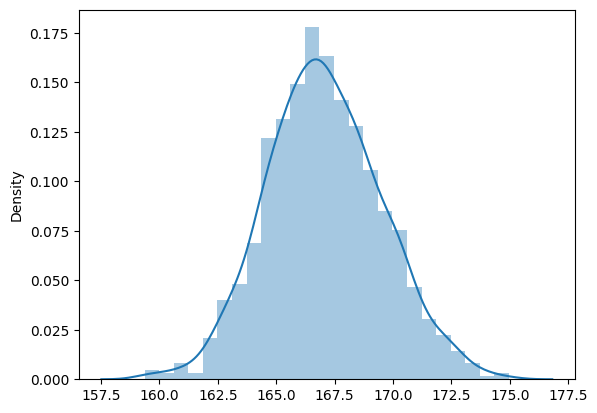

In [160]:
sns.distplot(array)#after clt perfect gussian

In [161]:
print(skew(data['Height_cm']))
print(skew(array))

0.04400206152538272
0.10523650946697266


In [162]:
print(kurtosis(data['Height_cm']),kurtosis(array))

-1.1738105912122145 0.023163140637267432


In [163]:
#kstest
from scipy.stats import kstest

In [164]:
value,p_value=kstest(data['Height_cm'],cdf='norm',N=20)

In [165]:
value,p_value

(1.0, 0.0)

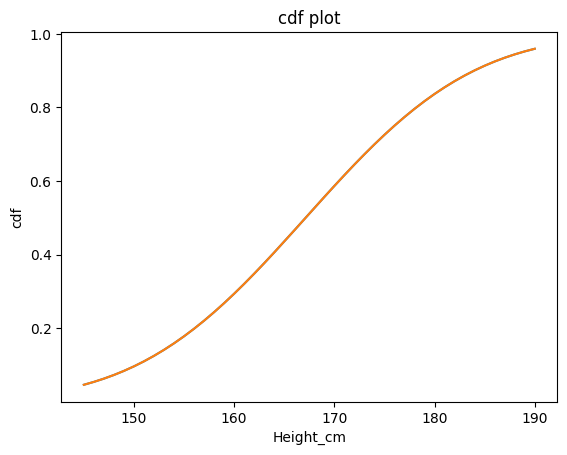

In [166]:
import math# its write from gusiian distribution  its my obeservation
def cdf(x):
    sorted=np.sort(x)
    lst=[]
    mean=np.mean(x)
    std=np.std(x)
    for i in x:
        s=(i-mean)/(std*np.sqrt(2))
        er=math.erf(s)
        final=(1/2)*(1+er)
        lst.append(final)
    return lst

x=np.sort(data['Height_cm'])
z=cdf(x)
import matplotlib.pyplot as plt
plt.plot(x,z)
plt.plot(x, z)
plt.xlabel("Height_cm")
plt.ylabel("cdf")
plt.title("cdf plot")
plt.show()


In [167]:
#weght

In [168]:
data['Weight_kg']

0      118
1       62
2       83
3      116
4       61
      ... 
995     52
996     52
997     70
998     41
999     55
Name: Weight_kg, Length: 1000, dtype: int64

<Axes: ylabel='Weight_kg'>

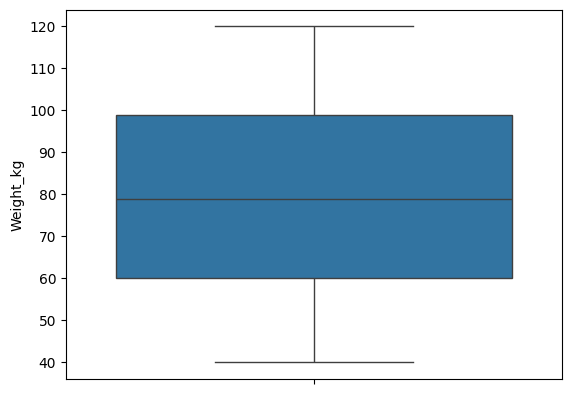

In [169]:
sns.boxplot(data['Weight_kg'])

In [170]:
kurtosis(data['Weight_kg'])

-1.1572742312023814

In [171]:
def clt(data,sample,sample_size):
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))

    mean_array = np.array(sample_mean)
    
    return mean_array, np.mean(mean_array)

data1=data['Age']
sample_data=1000
sample_size=30
array, estimated_mean = estimation_clt(data1, 1000, 30)
array,estimated_mean

(array([39.96666667, 42.46666667, 37.06666667, 38.86666667, 44.56666667,
        46.9       , 40.36666667, 43.43333333, 47.2       , 43.3       ,
        38.23333333, 45.2       , 42.06666667, 40.63333333, 42.36666667,
        41.23333333, 42.53333333, 38.96666667, 40.96666667, 40.23333333,
        41.26666667, 47.63333333, 39.3       , 41.9       , 45.2       ,
        45.76666667, 41.66666667, 39.6       , 39.73333333, 43.8       ,
        43.33333333, 45.26666667, 42.56666667, 42.8       , 40.53333333,
        39.16666667, 42.86666667, 42.6       , 41.3       , 42.63333333,
        42.06666667, 41.86666667, 45.2       , 43.        , 44.1       ,
        41.43333333, 39.96666667, 41.46666667, 38.83333333, 42.43333333,
        43.1       , 41.33333333, 44.8       , 40.9       , 39.93333333,
        48.4       , 41.43333333, 38.63333333, 41.63333333, 41.16666667,
        40.5       , 38.16666667, 42.1       , 43.03333333, 38.23333333,
        45.1       , 41.93333333, 42.16666667, 49.3

In [172]:
def bostraping():
    #pass

SyntaxError: incomplete input (434224652.py, line 2)

In [ ]:
#adtest

In [174]:
data.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'Age_categoric'],
      dtype='object')

C:\Users\BIREN KUMAR NAYAK\AppData\Local\Temp\ipykernel_28068\529948057.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Weight_kg'])


<Axes: xlabel='Weight_kg', ylabel='Density'>

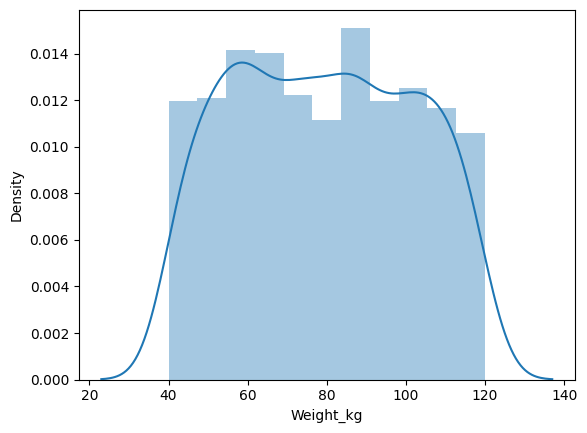

In [175]:
#weightkg
sns.distplot(data['Weight_kg'])

In [ ]:
probplot(data['Weight_kg'],dist='norm',plot=plt)
plt.show()

In [ ]:
import math# its write from gusiian distribution  its my obeservation
def cdf(x):
    sorted=np.sort(x)
    lst=[]
    mean=np.mean(x)
    std=np.std(x)
    for i in x:
        s=(i-mean)/(std*np.sqrt(2))
        er=math.erf(s)
        final=(1/2)*(1+er)
        lst.append(final)
    return lst

In [ ]:
x=np.sort(data['Weight_kg'])
z=cdf(x)
import matplotlib.pyplot as plt
plt.plot(x,z)
plt.plot(x, z)
plt.xlabel("weight_kg")
plt.ylabel("cdf")
plt.title("cdf plot")
plt.show()

In [ ]:
def estimation_clt(data1, sample_data, sample_size):
    sample_mean = []
    for i in range(sample_data):
        data = np.array(data1).flatten() 
        sample = np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))

    mean_array = np.array(sample_mean)
    
    return mean_array, np.mean(mean_array),np.mean(mean_array)
data1=data['Weight_kg']
sample_data=1000
sample_size=30
estimation_clt(data1, sample_data, sample_size)

In [176]:
def gusssian_emperical(z,k):
    mean=np.mean(z)
    std=np.std(z)
    ll=mean-3*std
    ul=mean+3*std
    return ll,ul
z=data['Weight_kg']
gusssian_emperical(z,1)

(11.613260086571913, 146.84873991342806)

In [ ]:
gusssian_emperical(z,2)

In [ ]:
gusssian_emperical(z,3)

In [ ]:
def bostrapping():#to get 95% interval
    #pass

In [ ]:
data

In [ ]:
data.groupby('Age_categoric')['Weight_kg'].mean()# obesrevation  for write it

In [ ]:
##BMI

In [ ]:
data['BMI']

In [ ]:
sns.distplot(data['BMI'])

In [ ]:
sns.boxplot(data['BMI'])

In [ ]:
qq_plot=probplot(data['BMI'],dist='norm',plot=plt)
plt.show()

In [ ]:
#bmi is gussisan bcz its combo of height and weght

In [ ]:
def imperial_method(x,l):
    mean=np.mean(x)
    std=np.std(x)
    ll=mean+k*std
    ul=mean+k*std
    return ll,ul

x=data['BMI']
imperial_method(x,1)

In [ ]:
imperial_method(x,2)

In [ ]:
imperial_method(x,3)

In [ ]:
def cdf():
    #pass

In [ ]:
def clt():
    #pass

In [ ]:
def boostraping(data1, sample_data, sample_size, ci):
    data = np.array(data1).flatten()   # make data 1D
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data1, size=sample_size, replace=True)
        sample_mean.append(np.mean(sample))
    sample_mean = np.array(sample_mean)
    lower = np.percentile(sample_mean,   2.5)
    upper = np.percentile(sample_mean,  97.5)

    return lower, upper
data1=data['BMI']
sample_data=1000
sample_size=30
xi=0.95
boostraping(data1, sample_data, sample_size, ci)

In [ ]:
###Activity_Level
data.columns

In [ ]:
data['Activity_Level']

In [ ]:
data['Activity_Level'].value_counts().plot(kind='bar')

In [ ]:
data.groupby('Age_categoric')['Activity_Level'].value_counts()
## Activity_Level for young old or adult is high  

In [ ]:
data['Sugar_Level']#check adtest,skew,kstest

In [ ]:
sns.distplot(data['Sugar_Level'])

In [ ]:
sns.boxplot(data['Sugar_Level'])

In [ ]:
data['Sugar_Level'].skew()

In [ ]:
data['Sugar_Level'].kurtosis()

In [ ]:
from scipy import stats

In [ ]:
stats.kstest(data['Sugar_Level'],cdf='norm',N=20)

In [ ]:
data.columns

In [ ]:
#sugar_level
data['Sugar_Level']

In [ ]:
sns.distplot(data['Sugar_Level'])

In [ ]:
sns.boxplot(data['Sugar_Level'])

In [ ]:
data['Sugar_Level'].skew()

In [ ]:
data['Sugar_Level'].kurtosis()

In [ ]:
probplot(data['Sugar_Level'],dist='norm',plot=plt)
plt.show()

In [ ]:
def clt():

In [ ]:
def cdf():

In [ ]:
def chebiousenquality():
    #pass

In [ ]:
def boostrap():

In [ ]:
kstest(data['Sugar_Level'],cdf='norm',N=20)

In [ ]:
data.columns

## Cholestrol

In [ ]:
data['Cholesterol']# if you have numerical columns

In [ ]:
sns.distplot(data['Cholesterol'])

In [ ]:
sns.boxplot(data['Cholesterol'])

In [ ]:
probplot(data['Cholesterol'],dist='norm',plot=plt)
plt.show()

In [ ]:
print(data['Cholesterol'].skew())
print(data['Cholesterol'].kurtosis())

In [ ]:
import numpy as np

def estimation_clt(data, sample_data, sample_size):
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))

    mean_array = np.array(sample_mean)
    
    return mean_array, np.mean(mean_array)

In [ ]:
import numpy as np

def boostraping(data1, sample_data, sample_size, ci):
    data = np.array(data1).flatten()   # make data 1D
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data1, size=sample_size, replace=True)
        sample_mean.append(np.mean(sample))
    sample_mean = np.array(sample_mean)
    lower = np.percentile(sample_mean, (1-ci)/2 * 100)
    upper = np.percentile(sample_mean, (1+ci)/2 * 100)

    return lower, upper

data1=data['Cholesterol']
sample_data=1000
sample_size=30
ci=0.95
print('confindence interval:')
boostraping(data1, sample_data, sample_size, ci)

In [ ]:
def std_chebisius_enqulity(mean, std, k):
    ll = mean - k * std   # lower limit
    ul = mean + k * std   # upper limit
    per = 1 - (1 / k**2)  # minimum probability
    
    return ll, ul, per
df = data['Cholesterol']
mean = np.mean(df)
std = np.std(df)
k = 3
# range estimation
ll, ul, per = std_chebisius_enqulity(mean, std, k)
print("Lower Limit:", ll)
print("Upper Limit:", ul)
print("Minimum Data Percentage:", per * 100, "%")

In [ ]:
def imperial_method(x,l):
    mean=np.mean(x)
    std=np.std(x)
    ll=mean+k*std
    ul=mean+k*std
    return ll,ul

x=data['Cholesterol']
imperial_method(x,1)

In [ ]:
def cdf(x):
    sorted=np.sort(x)
    lst=[]
    mean=np.mean(x)
    std=np.std(x)
    for i in x:
        s=(i-mean)/(std*np.sqrt(2))
        er=math.erf(s)
        final=(1/2)*(1+er)
        lst.append(final)
    return lst

x=np.sort(data['Cholesterol'])
z=cdf(x)
import matplotlib.pyplot as plt
plt.plot(x,z)
plt.plot(x, z)
plt.xlabel("Cholestrol")
plt.ylabel("cdf")
plt.title("cdf plot")
plt.show()

In [ ]:
from scipy.stats import kstest
value,p_value=kstest(data['Cholesterol'],cdf='norm',N=20)
value,p_value

In [ ]:
from scipy.stats import anderson#adtest
anderson(data['Cholesterol'],dist='norm')

In [ ]:
#goal

In [ ]:
data['Goal'].value_counts()

In [ ]:
sns.barplot(data['Goal'].value_counts())

In [ ]:
def fun(x):
    if x==0:
        return 'no goal'
    if x==1:
        return 'mid goal'
    else:
        return 'high goal'
        
data['goal_for_diet']=data['Goal'].apply(fun)

In [ ]:
d

In [ ]:
data.groupby('goal_for_diet')['Age'].mean()

In [ ]:
data.groupby('goal_for_diet')['Age'].max()

In [ ]:
data.groupby('goal_for_diet')['Age'].min()

In [ ]:
#taget columns
data['Diet'].value_counts()

In [ ]:
sns.countplot(data['Diet'])

In [ ]:
data

In [ ]:
pd.crosstab(data['Diet'],data['goal_for_diet'])

In [ ]:
data.groupby('Diet')['Age_categoric'].count()

In [ ]:
data['Diet']

In [ ]:
def fun(x):
    if x=='Low Carb':
        return 0
    elif x=='Diabetic':
        return 1
    else:
        return 2
data['Encode_diet']=data['Diet'].apply(fun)

In [ ]:
data

In [ ]:
data['Diet'].mode()

In [ ]:
(data['Diet'].value_counts(normalize=True)*100)/len(data['Diet'])

# Biavariate Anyalisis

In [48]:
import pandas as pd
data_dupicate=pd.read_csv('diet.csv')
data_dupicate.head(1)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb


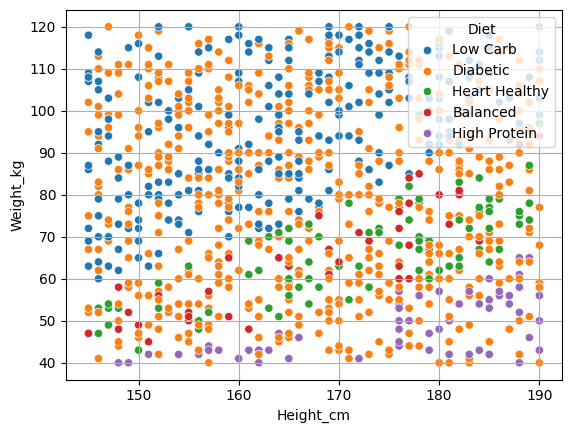

In [49]:
sns.scatterplot(data_dupicate,x='Height_cm',y='Weight_kg',hue='Diet')
plt.grid()
plt.show()

In [50]:
np.corrcoef(data_dupicate['Height_cm'],data_dupicate['Weight_kg'])

array([[ 1.        , -0.02008359],
       [-0.02008359,  1.        ]])

In [51]:
from scipy.stats import  spearmanr
data=spearmanr(data_dupicate['Height_cm'],data_dupicate['Weight_kg'])
data# here its no realtion between heaight and weight  in the genrally way its strong positive realtion but here we not get any relation no sense

SignificanceResult(statistic=-0.018549137425943194, pvalue=0.5579480975816835)

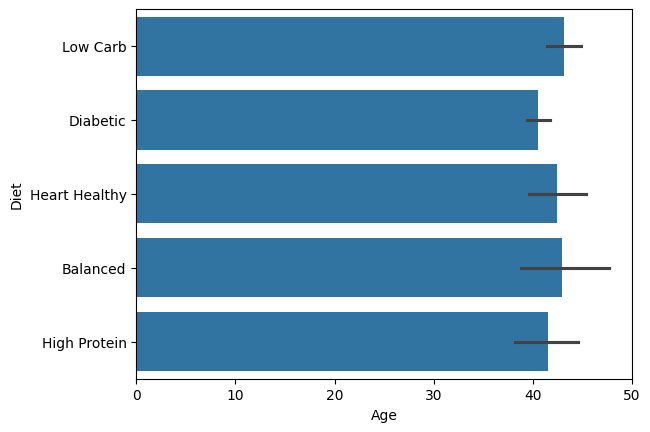

In [52]:
sns.barplot(data=data_dupicate,x='Age',y='Diet')
plt.show()

###numerical columns and categorical 

In [53]:
data_dupicate.groupby('Gender')['Diet'].count()

Gender
0    524
1    476
Name: Diet, dtype: int64

In [54]:
# without crosstab we can use in this way to craete matix for categorical columns and use chiasquare test for this
data_dupicate['Diet'].unique()

array(['Low Carb', 'Diabetic', 'Heart Healthy', 'Balanced',
       'High Protein'], dtype=object)

In [55]:
data_dupicate['Gender'].unique()

array([0, 1], dtype=int64)

In [56]:
male_low=(data_dupicate[(data_dupicate['Diet']=='Low Carb')  & (data_dupicate['Gender']==0)]).shape[0]
male_diabetic=(data_dupicate[(data_dupicate['Diet']=='Diabetic')  & (data_dupicate['Gender']==0)]).shape[0]
male_heart=(data_dupicate[(data_dupicate['Diet']=='Heart Healthy')  & (data_dupicate['Gender']==0)]).shape[0]
male_balance=(data_dupicate[(data_dupicate['Diet']=='Balanced')  & (data_dupicate['Gender']==0)]).shape[0]
male_high=(data_dupicate[(data_dupicate['Diet']=='High Protein')  & (data_dupicate['Gender']==0)]).shape[0]
feamale_low=(data_dupicate[(data_dupicate['Diet']=='Low Carb')  & (data_dupicate['Gender']==1)]).shape[0]
feamale_diabetic=(data_dupicate[(data_dupicate['Diet']=='Diabetic')  & (data_dupicate['Gender']==1)]).shape[0]
feamale_heart=(data_dupicate[(data_dupicate['Diet']=='Heart Healthy')  & (data_dupicate['Gender']==1)]).shape[0]
feamale_balance=(data_dupicate[(data_dupicate['Diet']=='Balanced')  & (data_dupicate['Gender']==1)]).shape[0]
feamale_high=(data_dupicate[(data_dupicate['Diet']=='High Protein')  & (data_dupicate['Gender']==1)]).shape[0]
observation_matrix=np.array([[male_low,male_diabetic,male_heart,male_balance,male_high]
                             ,[feamale_low,feamale_diabetic,feamale_heart,feamale_balance,feamale_high]])

In [57]:
from scipy.stats import chi2_contingency
chi2_contingency(observed=observation_matrix)

Chi2ContingencyResult(statistic=5.8390950130281905, pvalue=0.2114913263745345, dof=4, expected_freq=array([[133.62 , 282.436,  48.208,  23.056,  36.68 ],
       [121.38 , 256.564,  43.792,  20.944,  33.32 ]]))

In [58]:
pd.crosstab(data_dupicate['Gender'],data_dupicate['Diet'])

Diet,Balanced,Diabetic,Heart Healthy,High Protein,Low Carb
Gender,,,,,
0,29,283,53,35,124
1,15,256,39,35,131


In [59]:
matices=np.matrix(pd.crosstab(data_dupicate['Gender'],data_dupicate['Diet']))
print(matices)
chi2_contingency(observed=matices)

[[ 29 283  53  35 124]
 [ 15 256  39  35 131]]


Chi2ContingencyResult(statistic=5.8390950130281905, pvalue=0.2114913263745345, dof=4, expected_freq=array([[ 23.056, 282.436,  48.208,  36.68 , 133.62 ],
       [ 20.944, 256.564,  43.792,  33.32 , 121.38 ]]))

# chisquare use  diet with all categorical columns

In [60]:
data_dupicate['Activity_Level'].unique()

array([0, 1, 2], dtype=int64)

In [ ]:
data_dupicate['Goal'].unique()

In [ ]:
cross=pd.crosstab(data_dupicate['Activity_Level'],data_dupicate['Diet'])
cross

In [ ]:
x=np.matrix(cross)
chi2_contingency(x)

In [ ]:
cross1=pd.crosstab(data_dupicate['Goal'],data_dupicate['Diet'])
y=np.matrix(cross1)
chi2_contingency(y)

In [ ]:
sns.barplot(data=data_dupicate,x='Goal',y='Diet')
plt.show()

In [ ]:
sns.barplot(data=data_dupicate,x='Activity_Level',y='Diet')
plt.show()

In [ ]:
sns.scatterplot(data=data_dupicate,x='Cholesterol',y='Sugar_Level',hue='Diet')
plt.legend()
plt.grid()
plt.show()

In [249]:
sns.scatterplot(data=data_dupicate,x='Age',y='BMI',hue='Diet')
plt.grid()
plt.show()

NameError: name 'data_dupicate' is not defined

In [ ]:
(data_dupicate[(data_dupicate['Gender']==0)&(data_dupicate['Activity_Level']==0)])

### statstical use fro 2 columns ad_categorical  anova tests  with data 

In [275]:
data

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Sugar_Level_categorical,Age_categoric
0,56,0,145,118,56.1,0,131,169,2,Low Carb,high,old
1,46,1,166,62,22.5,0,118,253,2,Diabetic,Normal,old
2,32,0,170,83,28.7,1,78,256,2,Diabetic,Normal,Adult
3,60,1,162,116,44.2,2,161,199,0,Diabetic,high,old
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy,Normal,young
...,...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic,high,young
996,43,1,165,52,19.1,2,175,156,2,Diabetic,high,Adult
997,21,0,159,70,27.7,1,126,177,0,Low Carb,Normal,young
998,36,1,171,41,14.0,2,149,249,0,Diabetic,high,Adult


In [276]:
young = data[data['Age_categoric'] == 'young']['Height_cm']
print(young)

4      158
15     159
17     155
22     178
36     158
      ... 
987    187
990    172
994    146
995    173
997    159
Name: Height_cm, Length: 172, dtype: int64


In [277]:
adult = data[data['Age_categoric'] == 'Adult']['Height_cm']
print(adult)

2      170
5      173
7      180
8      179
9      156
      ... 
989    166
991    173
996    165
998    171
999    175
Name: Height_cm, Length: 414, dtype: int64


In [263]:
old = data[data['Age_categoric'] == 'old']['Height_cm']
print(old)

0      145
1      166
3      162
6      156
12     155
      ... 
976    152
985    166
986    166
992    157
993    162
Name: Height_cm, Length: 414, dtype: int64


In [264]:
#find mean
old_mean=np.mean(old)
adult_mean=np.mean(adult)
young_mean=np.mean(young)

In [279]:
#find the overall mean for 
overall=np.mean(data['Height_cm'])

SSB=summation(i=1)*group_mean*overall_mean)**
SSB=summation ni(xi-bar-x-bar)**2

In [271]:
mean1=np.array(young)
mean1

array([158, 159, 155, 178, 158, 166, 188, 181, 149, 145, 156, 162, 159,
       160, 147, 182, 146, 155, 161, 174, 182, 177, 185, 164, 177, 146,
       177, 190, 183, 185, 152, 185, 162, 167, 156, 163, 166, 185, 147,
       177, 156, 168, 181, 168, 185, 180, 186, 184, 179, 188, 158, 146,
       183, 169, 180, 147, 156, 181, 150, 188, 164, 149, 173, 187, 186,
       154, 152, 177, 175, 175, 178, 182, 185, 169, 151, 163, 169, 177,
       172, 173, 188, 187, 190, 169, 148, 160, 148, 170, 174, 188, 188,
       189, 154, 160, 180, 183, 170, 180, 146, 146, 178, 167, 180, 173,
       186, 156, 160, 184, 174, 150, 166, 160, 162, 150, 156, 179, 174,
       162, 169, 177, 145, 160, 148, 176, 157, 158, 162, 178, 146, 155,
       153, 172, 151, 160, 182, 154, 183, 165, 181, 189, 179, 185, 173,
       186, 186, 145, 165, 172, 155, 187, 145, 190, 163, 151, 169, 165,
       176, 184, 184, 164, 165, 176, 156, 190, 184, 188, 155, 187, 172,
       146, 173, 159], dtype=int64)

In [274]:
mean=np.array(old)
mean

array([145, 166, 162, 156, 155, 177, 170, 178, 190, 148, 157, 159, 176,
       146, 164, 147, 163, 147, 182, 159, 169, 168, 188, 171, 169, 161,
       152, 171, 190, 168, 190, 169, 161, 188, 164, 153, 157, 162, 190,
       175, 176, 155, 189, 155, 166, 168, 156, 190, 176, 159, 172, 177,
       154, 184, 157, 183, 182, 183, 170, 159, 178, 188, 184, 147, 150,
       153, 153, 156, 152, 151, 155, 160, 170, 147, 155, 156, 189, 163,
       190, 180, 173, 176, 162, 162, 181, 179, 173, 159, 174, 175, 164,
       188, 176, 180, 159, 183, 147, 177, 170, 152, 180, 174, 186, 149,
       182, 189, 185, 164, 150, 172, 146, 181, 149, 184, 175, 158, 160,
       154, 154, 156, 185, 149, 152, 145, 172, 187, 181, 156, 172, 146,
       153, 173, 145, 179, 150, 181, 156, 164, 168, 178, 169, 183, 167,
       182, 167, 189, 160, 152, 165, 145, 173, 176, 182, 149, 166, 145,
       187, 161, 170, 184, 156, 152, 169, 163, 149, 185, 172, 146, 150,
       153, 177, 169, 185, 155, 190, 157, 167, 151, 159, 145, 15

In [272]:
mean_adult=np.array(adult)
mean_adult

array([170, 173, 180, 179, 156, 151, 173, 150, 176, 167, 173, 161, 179,
       185, 183, 173, 173, 155, 155, 171, 161, 172, 173, 165, 160, 164,
       150, 178, 179, 152, 190, 173, 159, 151, 173, 188, 147, 164, 159,
       174, 158, 151, 180, 166, 168, 152, 152, 165, 162, 169, 182, 152,
       185, 161, 160, 166, 176, 177, 185, 174, 177, 157, 170, 166, 146,
       186, 155, 150, 175, 176, 172, 164, 164, 148, 150, 166, 186, 158,
       157, 169, 189, 152, 188, 150, 176, 172, 154, 151, 165, 148, 172,
       164, 180, 178, 146, 178, 150, 156, 189, 162, 165, 159, 167, 158,
       158, 146, 181, 183, 169, 161, 179, 145, 156, 189, 167, 155, 154,
       173, 174, 145, 164, 187, 164, 181, 188, 159, 158, 181, 164, 170,
       177, 158, 186, 187, 175, 188, 164, 152, 178, 170, 174, 162, 171,
       190, 148, 145, 160, 158, 170, 185, 157, 153, 157, 148, 148, 182,
       163, 150, 178, 162, 163, 189, 155, 145, 168, 165, 179, 152, 154,
       146, 190, 153, 147, 170, 152, 146, 150, 178, 180, 167, 18

In [316]:
groups=[mean1,mean_adult,mean]


In [326]:
#observati
N=len(mean1)+len(mean_adult)+len(mean)

In [318]:
k=len(groups)

In [320]:
overall_mean=np.mean(np.concatenate(groups))
overall_mean

167.139

In [324]:
ssb=sum(len(g)*(np.mean(g)-overall_mean)**2 for g in groups)
ssw=sum(sum((x-np.mean(g))**2 for x in g) for g in groups)

In [330]:
# Degrees of freedom
df_between = k-1
df_within = N-k
# Mean squares
MSB = ssb/df_between
MSW = ssw/df_within
# F statistic
F = MSB/MSW

print("F-statistic:", F)

F-statistic: 1.7971132241018455


In [ ]:
#here nulll hypotheis rejected

# cholestrol for anova to age

In [298]:
def fun(x):
    if x<=200:
        return 'normal'
    elif x<140:
        return 'low'
    else:
        return 'high'
data['Cholesterol_categorical']=data['Cholesterol'].apply(fun)
data

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Sugar_Level_categorical,Age_categoric,Cholesterol_categorical
0,56,0,145,118,56.1,0,131,169,2,Low Carb,high,old,normal
1,46,1,166,62,22.5,0,118,253,2,Diabetic,Normal,old,high
2,32,0,170,83,28.7,1,78,256,2,Diabetic,Normal,Adult,high
3,60,1,162,116,44.2,2,161,199,0,Diabetic,high,old,normal
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy,Normal,young,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic,high,young,high
996,43,1,165,52,19.1,2,175,156,2,Diabetic,high,Adult,normal
997,21,0,159,70,27.7,1,126,177,0,Low Carb,Normal,young,normal
998,36,1,171,41,14.0,2,149,249,0,Diabetic,high,Adult,high


In [299]:
normal = data[data['Cholesterol_categorical'] == 'normal']['Age']
print(normal)

0      56
3      60
10     28
12     53
13     57
       ..
991    43
993    61
996    43
997    21
999    37
Name: Age, Length: 410, dtype: int64


In [302]:
high= data[data['Cholesterol_categorical'] == 'high']['Age']
print(high)

1      46
2      32
4      25
5      38
6      56
       ..
990    25
992    62
994    22
995    23
998    36
Name: Age, Length: 590, dtype: int64


In [331]:
from scipy.stats import f_oneway


f_stat, p_value = f_oneway(normal,high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 2.7424930738499222
p-value: 0.09802657132461695


In [ ]:
#sugarlevel

In [304]:
def fun(x):
    if x<=70:
        return 'low'
    elif x>126 and x<180:
        return 'high'
    else:
        return 'Normal'

In [305]:
data['Sugar_Level_categorical']=data['Sugar_Level'].apply(fun)
data['Sugar_Level_categorical']

0        high
1      Normal
2      Normal
3        high
4      Normal
        ...  
995      high
996      high
997    Normal
998      high
999      high
Name: Sugar_Level_categorical, Length: 1000, dtype: object

In [245]:
data['Sugar_Level_categorical'].value_counts()

Sugar_Level_categorical
Normal    497
high      495
low         8
Name: count, dtype: int64

In [246]:
not_high=len(data[data['Sugar_Level']>125])

513

In [281]:
len(data[data["Sugar_Level"] <=80])

88

In [282]:
len(data[(data["Sugar_Level"] >= 80) & (data["Sugar_Level"] <= 125)])

409

## permuation tests

In [9]:
data

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [26]:
male_heaight=data[data['Gender']==0]['Height_cm']
femal_height= data[data['Gender']==1]['Height_cm']
# we check the differnce of male and female
import numpy as np
def permutation_test(x, y, n):
    x = np.array(x)
    y = np.array(y)
    # combine samples 
    jumble_sample = np.concatenate((x, y))
    
    # observed difference
    D = abs(np.mean(x) - np.mean(y))
    
    g = len(x)
    total = len(jumble_sample)
    
    lst = []
    
    for i in range(n):
        # shuffle
        combine_sample = np.random.permutation(jumble_sample)
        
        # split samples
        new_sample1 = combine_sample[:g]
        new_sample2 = combine_sample[g:total]
        
        # difference of means
        difference = abs(np.mean(new_sample1) - np.mean(new_sample2))
        
        lst.append(difference)
    
    diff_array = np.sort(np.array(lst))
    
    c = 0
    for j in diff_array:
        if j >= D:
            c += 1
    
    p_value = c / n
    
    return p_value
permutation_test(male_heaight,femal_height,1000)


0.266

In [25]:
male_Weight_kg=data[data['Gender']==0]['Weight_kg']
femal_Weight_kg= data[data['Gender']==1]['Weight_kg']
def permutation_test(x, y, n):
    
    x = np.array(x)
    y = np.array(y)
    
    # combine samples
    jumble_sample = np.concatenate((x, y))
    
    # observed difference
    D = abs(np.mean(x) - np.mean(y))
    
    g = len(x)
    total = len(jumble_sample)
    
    lst = []
    
    for i in range(n):
        # shuffle
        combine_sample = np.random.permutation(jumble_sample)
        
        # split samples
        new_sample1 = combine_sample[:g]
        new_sample2 = combine_sample[g:total]
        
        # difference of means
        difference = abs(np.mean(new_sample1) - np.mean(new_sample2))
        
        lst.append(difference)
    
    diff_array = np.sort(np.array(lst))
    
    c = 0
    for j in diff_array:
        if j >= D:
            c += 1
    
    p_value = c / n
    
    return p_value
permutation_test(male_Weight_kg,femal_Weight_kg,1000)

0.223

In [15]:
#calculate 95% interval of chol level use chebisus enquality
import numpy as np

def boostraping(data1, sample_data, sample_size, ci):
    data = np.array(data1).flatten()   # make data 1D
    sample_mean = []
    for i in range(sample_data):
        sample = np.random.choice(data1, size=sample_size, replace=True)
        sample_mean.append(np.mean(sample))
    sample_mean = np.array(sample_mean)
    lower = np.percentile(sample_mean, (1-ci)/2 * 100)
    upper = np.percentile(sample_mean, (1+ci)/2 * 100)

    return lower, upper

data1=data['Cholesterol']
sample_data=1000
sample_size=30
ci=0.95
print('confindence interval:')
boostraping(data1, sample_data, sample_size, ci)

confindence interval:


(197.2325, 225.10333333333332)

In [22]:
# the sugar level  of male  125. but afte taking  sample of 60 people it std 130 population  std=30
def z_test(y, mu, std):
    y= np.array(y)
    x_bar = np.mean(y)
    n = len(y)
    z = (x_bar - mu) / (std / np.sqrt(n))
    return z
y=data['Sugar_Level']
mu=np.mean(y) 
std=np.std(y)
z_test(y,mu,std)

0.0

In [24]:
data['Sugar_Level'].std()

31.838012108406126

# multivariate_anyliss

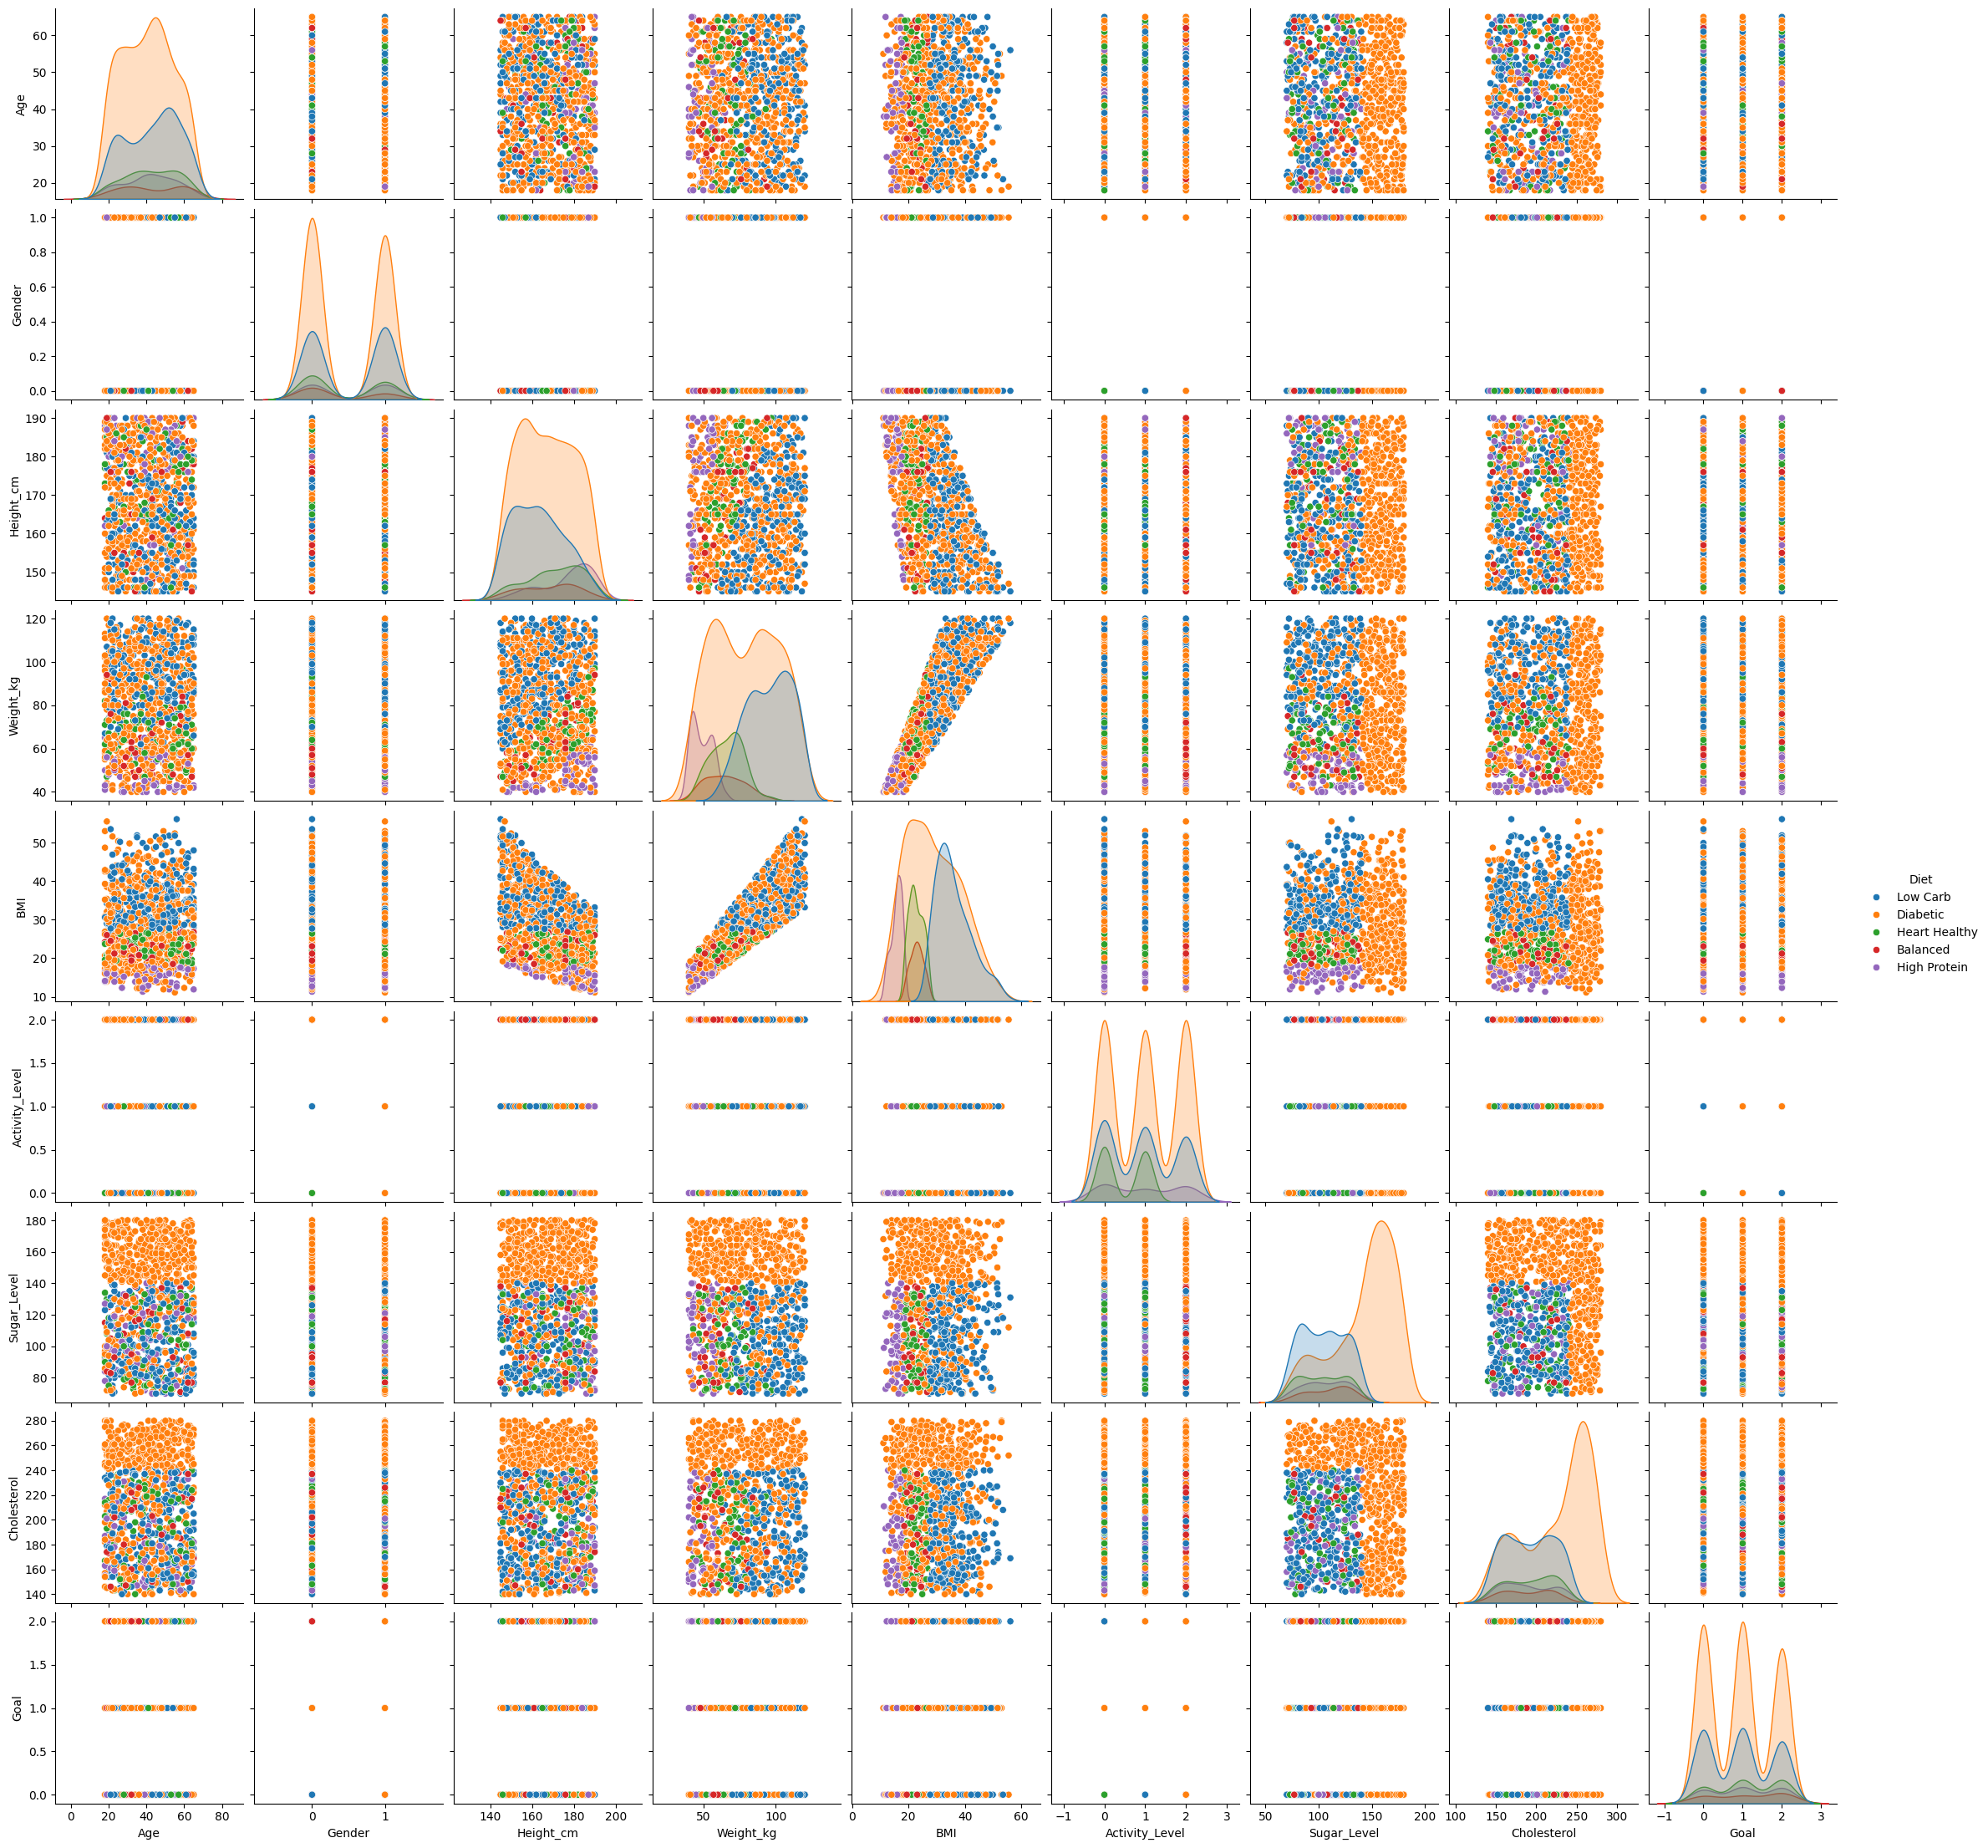

In [34]:
sns.pairplot(data,hue='Diet')
plt.show()

In [38]:
data.corr(method='pearson',numeric_only=True)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal
Age,1.000000,-0.028480,-0.045504,0.031570,0.044260,-0.019433,-0.033849,-0.023504,-0.003518
Gender,-0.028480,1.000000,-0.035237,0.037671,0.048753,-0.047744,-0.000108,0.016309,0.049793
Height_cm,-0.045504,-0.035237,1.000000,-0.020084,-0.487809,0.035577,-0.011179,-0.017428,-0.030967
Weight_kg,0.031570,0.037671,-0.020084,1.000000,0.870239,-0.019191,-0.041038,0.000649,0.015662
BMI,0.044260,0.048753,-0.487809,0.870239,1.000000,-0.034631,-0.026204,0.004125,0.025448
Activity_Level,-0.019433,-0.047744,0.035577,-0.019191,-0.034631,1.000000,0.047111,0.015233,0.000686
Sugar_Level,-0.033849,-0.000108,-0.011179,-0.041038,-0.026204,0.047111,1.000000,0.027882,-0.040996
Cholesterol,-0.023504,0.016309,-0.017428,0.000649,0.004125,0.015233,0.027882,1.000000,0.013310
Goal,-0.003518,0.049793,-0.030967,0.015662,0.025448,0.000686,-0.040996,0.013310,1.000000


In [39]:
data.corr(method='spearman',numeric_only=True)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal
Age,1.000000,-0.028047,-0.045322,0.032915,0.052065,-0.019246,-0.033535,-0.021035,-0.004877
Gender,-0.028047,1.000000,-0.035270,0.036828,0.053392,-0.048364,0.000017,0.017886,0.050168
Height_cm,-0.045322,-0.035270,1.000000,-0.018549,-0.464119,0.035828,-0.009886,-0.017103,-0.031319
Weight_kg,0.032915,0.036828,-0.018549,1.000000,0.885585,-0.019342,-0.039615,0.000567,0.015131
BMI,0.052065,0.053392,-0.464119,0.885585,1.000000,-0.036266,-0.035971,0.000959,0.018043
Activity_Level,-0.019246,-0.048364,0.035828,-0.019342,-0.036266,1.000000,0.046576,0.014733,0.000371
Sugar_Level,-0.033535,0.000017,-0.009886,-0.039615,-0.035971,0.046576,1.000000,0.028279,-0.040547
Cholesterol,-0.021035,0.017886,-0.017103,0.000567,0.000959,0.014733,0.028279,1.000000,0.014181
Goal,-0.004877,0.050168,-0.031319,0.015131,0.018043,0.000371,-0.040547,0.014181,1.000000


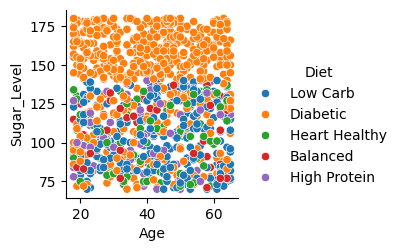

In [333]:
sns.pairplot(data=data,x_vars='Age',y_vars='Sugar_Level',hue='Diet')

                     Age    Gender  Height_cm  Weight_kg       BMI  \
Age             1.000000 -0.028480  -0.045504   0.031570  0.044260   
Gender         -0.028480  1.000000  -0.035237   0.037671  0.048753   
Height_cm      -0.045504 -0.035237   1.000000  -0.020084 -0.487809   
Weight_kg       0.031570  0.037671  -0.020084   1.000000  0.870239   
BMI             0.044260  0.048753  -0.487809   0.870239  1.000000   
Activity_Level -0.019433 -0.047744   0.035577  -0.019191 -0.034631   
Sugar_Level    -0.033849 -0.000108  -0.011179  -0.041038 -0.026204   
Cholesterol    -0.023504  0.016309  -0.017428   0.000649  0.004125   
Goal           -0.003518  0.049793  -0.030967   0.015662  0.025448   

                Activity_Level  Sugar_Level  Cholesterol      Goal  
Age                  -0.019433    -0.033849    -0.023504 -0.003518  
Gender               -0.047744    -0.000108     0.016309  0.049793  
Height_cm             0.035577    -0.011179    -0.017428 -0.030967  
Weight_kg            -0

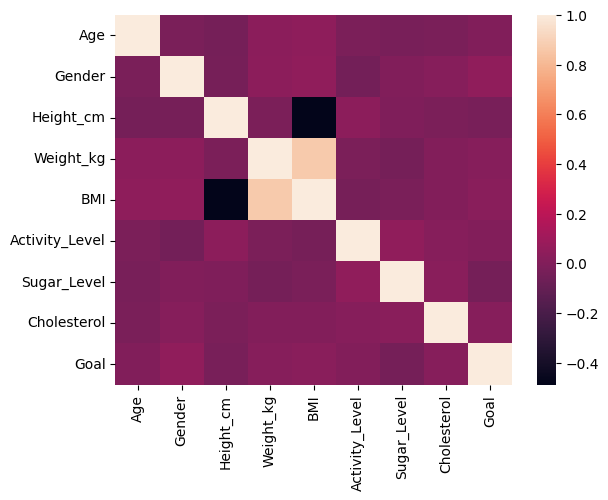

In [337]:
corr=data.corr(numeric_only=True)
print(corr)
sns.heatmap(corr)
plt.show()

SignificanceResult(statistic=-0.018549137425943194, pvalue=0.5579480975816835)